In [52]:

import cv2
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import PIL.Image

In [53]:
input_video_path = "two_channel.mp4"
output_csv_path = "single_results.csv"

In [54]:
# 1. Initialize Video Capture
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()

# List to store data for each frame
data_log = []

frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
display_every_n_frames = 100

cx = frame_width // 2
cy = frame_height // 2

window_size = 220

# Centered square crop window with bounds clamped to the frame
half_window = window_size // 2
x1 = cx - half_window
y1 = cy - half_window - 80
x2 = cx + half_window
y2 = cy + half_window - 80

# ROI (bottom-right of cropped frame)
roi_size = 50
prev_brightness = None
change_threshold = 10
brightness_frames = []



In [55]:
def split_contour(gradient):
    # Returns two contour parts after splitting along the best triangle edge.
    r1, r2 = 8, 128
    c = cv2.findNonZero(gradient)
    if c is None or len(c) < 3:
        return gradient.copy(), np.zeros_like(gradient)

    triangle = cv2.minEnclosingTriangle(c)[1]
    if triangle is None:
        return gradient.copy(), np.zeros_like(gradient)

    triangle = np.intp(triangle)
    score = np.zeros(3)
    for i in range(0, 3):
        grad_temp = gradient.copy()
        cv2.line(grad_temp, triangle[i][0], triangle[(i + 1) % 3][0], 0, 6)
        score[i] = cv2.countNonZero(grad_temp)

    idx = int(np.argmin(score))
    grad_work = gradient.copy()
    cv2.line(grad_work, triangle[idx][0], triangle[(idx + 1) % 3][0], 0, r1)
    g1 = grad_work.copy()
    cv2.line(grad_work, triangle[idx][0], triangle[(idx + 1) % 3][0], 0, r2)
    g2 = cv2.bitwise_xor(g1, grad_work)
    return (g1, g2)

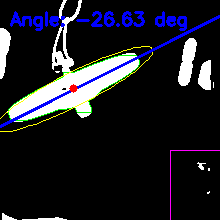


Success! Data saved to: single_results.csv
   frame  timestamp_sec  detected  line_point_x  line_point_y  line_dir_x  \
0      1       0.034026      True        102.21        113.50      0.9996   
1      2       0.068052      True        102.47        112.58      0.9997   
2      3       0.102078      True        102.95        113.55      0.9996   
3      4       0.136104      True        103.40        113.61      0.9996   
4      5       0.170130      True        103.60        113.47      0.9997   

   line_dir_y  line_angle_deg  longest_width_px  
0      0.0281            1.61            136.34  
1      0.0248            1.42            159.98  
2      0.0287            1.64            135.68  
3      0.0278            1.59            136.64  
4      0.0258            1.48            138.31  


In [56]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped = frame[y1:y2, x1:x2]

    # Enhance contrast (CLAHE) and convert back to BGR
    # lab = cv2.cvtColor(cropped, cv2.COLOR_BGR2LAB)
    # l, a, b = cv2.split(lab)
    # clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    # l2 = clahe.apply(l)
    # enhanced = cv2.merge([l2, a, b])
    # cropped_contrast = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    
    im = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    cropped_contrast = cv2.threshold(im, 100, 255, cv2.THRESH_BINARY)[1]
    
    # find average brightness in ROI (bottom-right corner)
    h, w = cropped_contrast.shape[:2]
    rx1 = max(w - roi_size, 0)
    ry1 = max(h - roi_size - 20, 0)
    roi_frame = cropped_contrast[ry1:h, rx1:w]
    current_brightness = cv2.mean(roi_frame)[0]
    # print(f"Frame {frame_count}: Brightness in ROI = {current_brightness:.2f}")

    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)

    prev_brightness = current_brightness

    # Threshold for bright/white pixels and clean small gaps/sticks
    # lower_white = np.array([100, 100, 100], dtype=np.uint8)
    # upper_white = np.array([250, 250, 250], dtype=np.uint8)
    # white_mask = cv2.inRange(cropped_contrast, lower_white, upper_white)
    
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    mask_no_sticks = cv2.morphologyEx(cropped_contrast, cv2.MORPH_OPEN, h_kernel, iterations=1)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    gradient = cv2.morphologyEx(mask_no_sticks, cv2.MORPH_GRADIENT, kernel)
    g1, g2 = split_contour(gradient)

    pixels = cv2.findNonZero(g2)
    ellipse2 = None
    if pixels is not None and len(pixels) >= 5:
        ellipse2 = cv2.fitEllipse(pixels)
    
    # kernel = np.ones((3, 3), np.uint8)
    # white_mask = cv2.morphologyEx(white_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    # h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    # mask_no_sticks = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, h_kernel, iterations=1)

    # Find contours and filter by area/thickness
    contours, _ = cv2.findContours(mask_no_sticks, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    kept = []
    min_thickness_px = 18
    min_area_px = 200
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area_px or len(c) < 5:
            continue
        (_, _), (w, h), _ = cv2.minAreaRect(c)
        if min(w, h) >= min_thickness_px:
            kept.append(c)
    contours = kept

    # Prepare minimal frame record
    frame_data = {
        "frame": frame_count,
        "timestamp_sec": frame_count / fps,
        "detected": False,
        "line_point_x": None,
        "line_point_y": None,
        "line_dir_x": None,
        "line_dir_y": None,
        "line_angle_deg": None,
        "longest_width_px": None,
    }

    # Pick largest contour and fit ellipse on its upper region
    best_cnt = None
    max_area = 0
    for cnt in contours:
        if len(cnt) >= 2:
            area = cv2.contourArea(cnt)
            if area > max_area:
                max_area = area
                best_cnt = cnt

    has_line = False
    fit_ellipse = None
    x0 = y0 = vx = vy = angle_deg = longest_width = 0.0

    if best_cnt is not None and max_area > 30:
        pts = best_cnt.reshape(-1, 2)
        y_min = int(np.min(pts[:, 1]))
        y_max = int(np.max(pts[:, 1]))
        y_cut = y_min + int(0.70 * (y_max - y_min))
        upper_pts = pts[pts[:, 1] <= y_cut]
        fit_pts = upper_pts if len(upper_pts) >= 5 else pts

        M = cv2.moments(best_cnt)
        if M["m00"] > 0:
            cx = float(M["m10"] / M["m00"])
            cy = float(M["m01"] / M["m00"])
        else:
            cx = float(np.mean(pts[:, 0]))
            cy = float(np.mean(pts[:, 1]))

        if len(fit_pts) >= 10:
            dist = np.sqrt((fit_pts[:, 0] - cx) ** 2 + (fit_pts[:, 1] - cy) ** 2)
            r_keep = np.percentile(dist, 90)
            trimmed = fit_pts[dist <= r_keep]
            if len(trimmed) >= 5:
                fit_pts = trimmed

        if len(fit_pts) >= 5:
            raw_ellipse = cv2.fitEllipse(fit_pts.reshape(-1, 1, 2))
            (_, _), (d1, d2), ell_angle = raw_ellipse
            x0, y0 = cx, cy
            fit_ellipse = ((x0, y0), (d1, d2), ell_angle)
            major = max(float(d1), float(d2))
            minor = min(float(d1), float(d2))
            angle_deg = float(ell_angle)
            if d2 > d1:
                angle_deg += 90.0
            angle_deg = ((angle_deg + 90.0) % 180.0) - 90.0
            longest_width = major
            angle_rad = math.radians(angle_deg)
            vx = math.cos(angle_rad)
            vy = math.sin(angle_rad)
            has_line = True

    if has_line:
        frame_data.update({
            "detected": True,
            "line_point_x": round(float(x0), 2),
            "line_point_y": round(float(y0), 2),
            "line_dir_x": round(float(vx), 4),
            "line_dir_y": round(float(vy), 4),
            "line_angle_deg": round(float(angle_deg), 2),
            "longest_width_px": round(float(longest_width), 2),
        })

    # Build overlay on cropped_contrast and draw diagnostics
    overlay = cv2.cvtColor(cropped_contrast, cv2.COLOR_GRAY2BGR)
    if len(contours) > 0:
        cv2.drawContours(overlay, contours, -1, (0, 255, 0), 1)
    if fit_ellipse is not None:
        cv2.ellipse(overlay, fit_ellipse, (0, 255, 255), 1)
    # if ellipse2 is not None:
    #     cv2.ellipse(overlay, ellipse2, (0, 0, 255), 1)
    if has_line:
        h, w = overlay.shape[:2]
        L = max(h, w)
        pt1 = (int(x0 - vx * L), int(y0 - vy * L))
        pt2 = (int(x0 + vx * L), int(y0 + vy * L))
        cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
        cv2.circle(overlay, (int(x0), int(y0)), 4, (0, 0, 255), -1)
        cv2.putText(overlay, f"Angle: {angle_deg:.2f} deg", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        cv2.rectangle(overlay, (rx1, ry1), (w, h), (255, 0, 255), 1)

    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    # Periodic visual check using cropped_contrast with overlays
    if frame_count % display_every_n_frames == 0:
        # plt.figure(figsize=(8, 4))
        # plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        # plt.title(f"Frame {frame_count}: Line Overlay")
        # plt.axis("off")
        # plt.show()
        frame = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        img = PIL.Image.fromarray(frame)
        clear_output(wait=True)
        display(img)

# Clean up and save results
cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nSuccess! Data saved to: {output_csv_path}")
print(df.head())

[819, 998, 1176, 1355, 1533, 1714, 1893, 2072, 2252, 2431]


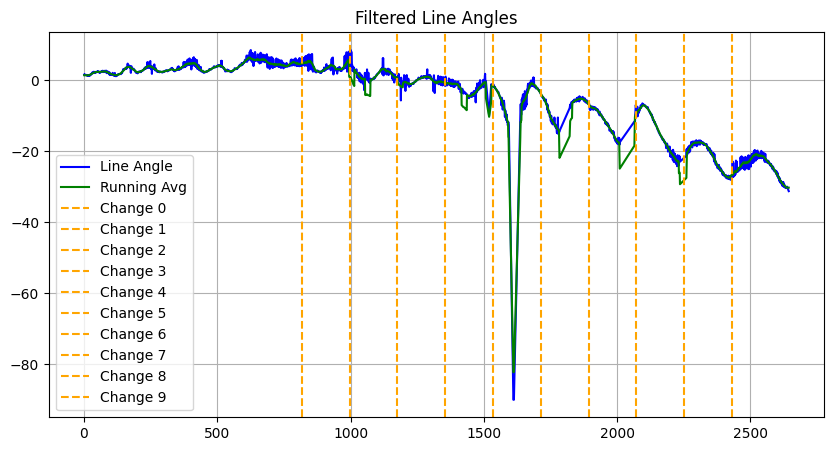

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and filter detections
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Remove outliers using n-period running average and variance
n = 20  # Window size
col = 'line_angle_deg'

# Compute running average on the current (detected) series
run_avg = df[col].rolling(window=n, center=True).mean().bfill().ffill()
run_var = df[col].rolling(window=n, center=True).var().bfill().ffill()

# Filter points outside threshold (aligned to the same index)
threshold = 8
mask = (abs(df[col] - run_avg) <= threshold)
df = df[mask].copy()
run_avg = run_avg[mask]

# Parameters for segment means
# change_buffer = 10
# step = 240

mean_angles = []
mean_angle_times = []

# # Compute segment means from start to end dynamically
# # num_segments = (len(df) + step - 1) // step  # ceiling
# for i in range(10):
#     time_start = i * step + change_buffer
#     time_end = (i + 1) * step - change_buffer
#     seg = df['line_angle_deg'].iloc[time_start:time_end]
#     mean_angles.append(seg.mean())
#     mean_angle_times.append(int(df['frame'].iloc[time_start]))

print(brightness_frames)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df['frame'].values, df['line_angle_deg'].values, 'b-', label='Line Angle')
plt.plot(df['frame'].values, run_avg.values, 'g-', label='Running Avg')

for i, bt in enumerate(brightness_frames):
    plt.axvline(bt, color='orange', linestyle='--', label=f'Change {i}')
if mean_angles:
    plt.scatter(mean_angle_times, mean_angles, c='r', label='Segment Means')
plt.title('Filtered Line Angles'); plt.legend(); plt.grid(True)
plt.show()

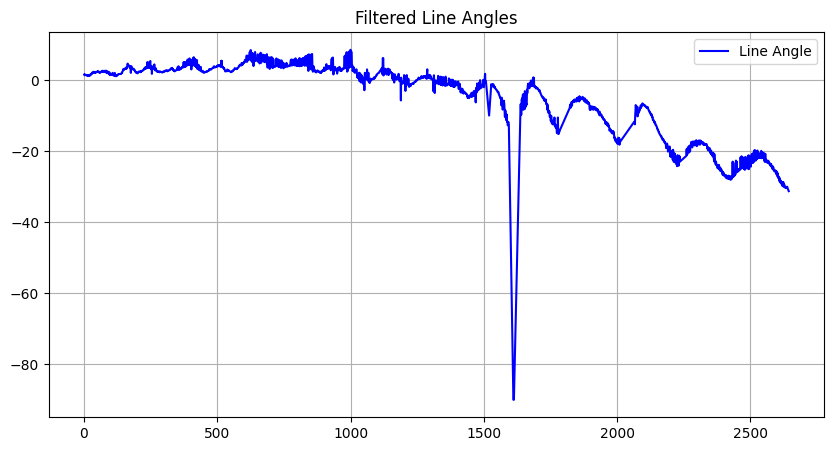

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(df['frame'], df['line_angle_deg'], 'b-', label='Line Angle')
plt.title('Filtered Line Angles'); plt.legend(); plt.grid(True)
plt.show()

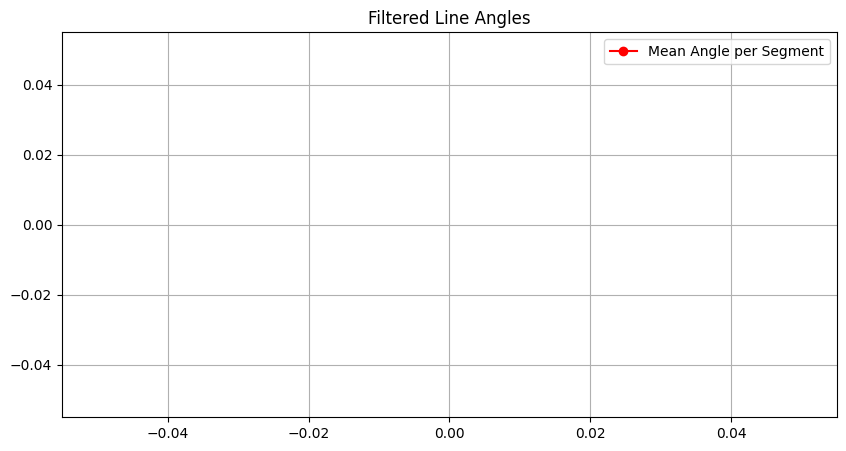

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(mean_angle_times, mean_angles, 'ro-', label='Mean Angle per Segment')
plt.title('Filtered Line Angles'); plt.legend(); plt.grid(True)
plt.show()